# Как работает учет позиционирования

In [121]:
# Импорты
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

## Формирование последовательности  (монотонная)
`out # torch.Size([1, max_len, d_model])`

In [ ]:
# Параметры
max_len = 100 # длина последовательности
d_model = 20 # размерность вектора каждой позиции

In [177]:
seq = list(range(1, max_len+1))
# seq

In [178]:
input_proj = nn.Linear(1, d_model)

In [180]:
x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # [max_len, 1]
# print(x)

In [181]:
out = input_proj(x)
out.shape # [max_len, d_model]

torch.Size([1, 100, 20])

## Формирование последовательности (не монотонная - 1)
`out # torch.Size([1, max_len, d_model])`

In [190]:
# Параметры
max_len = 5 # длина последовательности
d_model = 4 # размерность вектора каждой позиции

In [191]:
seq = ['may', 'june', 'july', 'august', 'october'] # длина доолжна совпасть с max_len !!!!

In [192]:
# Словарь, отображающий слова в числа
vocab = {word: idx for idx, word in enumerate(sorted(set(seq)))}
print(vocab)  # {'august': 0, 'july': 1, 'june': 2, 'may': 3, 'october': 4}

{'august': 0, 'july': 1, 'june': 2, 'may': 3, 'october': 4}


In [193]:
# Преобразуем слова в индексы
seq_ids = [vocab[word] for word in seq]  # [3, 2, 1, 0, 4]

In [198]:
input_proj = nn.Linear(1, d_model)

In [199]:
# Преобразуем в тензор
x = torch.tensor(seq_ids, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # [1, max_len, 1]
x.shape

torch.Size([1, 5, 1])

In [200]:
# Проекция
out = input_proj(x)
out.shape # [1, max_len, d_model]

torch.Size([1, 5, 4])

## Формирование последовательности (не монотонная - 2)
`out # torch.Size([1, max_len, d_model])`

In [202]:
# Параметры
max_len = 5 # длина последовательности
d_model = 4 # размерность вектора каждой позиции

In [203]:
seq = ['may', 'june', 'july', 'august', 'october']

# Создание словаря
vocab = {word: idx for idx, word in enumerate(sorted(set(seq)))}
vocab_size = len(vocab)

# Преобразуем последовательность в индексы
seq_ids = [vocab[word] for word in seq]  # [3, 2, 1, 0, 4]
x = torch.tensor(seq_ids, dtype=torch.long).unsqueeze(0)  # [1, 5]

In [204]:
# Здесь уже не через линейную модель а непосредственно преобразование в эмбеддинги
# Эмбеддинги
embedding = nn.Embedding(vocab_size, d_model)
out = embedding(x)  # [1, max_len, d_model]
out

tensor([[[-0.3774, -0.0514, -1.0876, -1.2557],
         [-0.0370, -1.4733, -0.1992,  0.4201],
         [ 1.3594,  0.1664,  0.5488, -1.0568],
         [-0.9892,  0.4537,  0.5635,  1.2938],
         [ 1.6540, -0.3577,  0.6448,  1.0026]]], grad_fn=<EmbeddingBackward0>)

## Получение эмбеддингов позиционирования (`pos_emb`)

In [205]:
def generate_sinusoidal_positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)  # чётные индексы
    pe[:, 1::2] = torch.cos(position * div_term)  # нечётные индексы
    return pe

In [206]:
pe = generate_sinusoidal_positional_encoding(max_len, d_model)
pe.shape # [max_len, d_model]

torch.Size([5, 4])

In [207]:
pos_emb = pe.unsqueeze(0)
pos_emb.shape # [1, max_len, d_model]

torch.Size([1, 5, 4])

## Результат

In [208]:
# Эмбеддинги входной последовательности с учетом позиций
x_with_pos = out + pos_emb
x_with_pos # [1, max_len, d_model]

tensor([[[-0.3774,  0.9486, -1.0876, -0.2557],
         [ 0.8045, -0.9330, -0.1892,  1.4201],
         [ 2.2687, -0.2497,  0.5688, -0.0570],
         [-0.8481, -0.5363,  0.5935,  2.2933],
         [ 0.8972, -1.0114,  0.6848,  2.0018]]], grad_fn=<AddBackward0>)

Посчитаем косинусные сходства между 5 эмбеддингами без учета позиций и с учетом.

In [209]:
import torch.nn.functional as F

### Без учета позиций

In [210]:
# out: # [1, max_len, d_model] — уберем размерность батча
emb = out.squeeze(0)  # # [max_len, d_model]

# Заготовка нулевой матрицы
similarities = torch.zeros(d_model, d_model)

# Расчет косинусного сходства между всеми парами: (i, j)
for i in range(d_model):
    for j in range(d_model):
        sim = F.cosine_similarity(emb[i].unsqueeze(0), emb[j].unsqueeze(0))
        similarities[i, j] = sim

### С учетом позиций

In [211]:
# x_with_pos: [1, max_len, d_model] — уберем размерность батча
emb_pos = x_with_pos.squeeze(0)  # [max_len, d_model]

# Заготовка нулевой матрицы
similarities_pos = torch.zeros(d_model, d_model)

# Косинусное сходство между всеми парами: (i, j)
for i in range(d_model):
    for j in range(d_model):
        sim = F.cosine_similarity(emb_pos[i].unsqueeze(0), emb_pos[j].unsqueeze(0))
        similarities_pos[i, j] = sim

In [212]:
print("Косинусное сходство между позициями (без учета позиции):")
print(similarities)
print("_______________________")
print("Косинусное сходство между позициями (с учетом позиции):")
print(similarities_pos)

Косинусное сходство между позициями (без учета позиции):
tensor([[ 1.0000, -0.0840,  0.0675, -0.6215],
        [-0.0840,  1.0000, -0.3027, -0.0728],
        [ 0.0675, -0.3027,  1.0000, -0.7196],
        [-0.6215, -0.0728, -0.7196,  1.0000]], grad_fn=<CopySlices>)
_______________________
Косинусное сходство между позициями (с учетом позиции):
tensor([[ 1.0000, -0.4707, -0.4766, -0.3649],
        [-0.4707,  1.0000,  0.4205,  0.6094],
        [-0.4766,  0.4205,  1.0000, -0.2616],
        [-0.3649,  0.6094, -0.2616,  1.0000]], grad_fn=<CopySlices>)


📌 Что мы получили.  
Значения в ячейках [i, j] в матрицах отражают __косинусное сходство__ (очевидно, обратная величина косинусного расстояния) между эмбеддингами токенов в позициях i и j. Чем ближе значение к 1, тем похожее поведение в модели, а если ближе к 0 или -1 — тем более они различны.   

Как видим, добавление позиционной информации корректирует эмбеддинги так, что у более близких значений величина косинусного сходства возрастает

## Полезный диалог с "известным" чатом

__Вопрос: по какому принципу формируются эмбеддинги, например для числовой последовательности?__

<small><font color = 'lightgreen'>__Ответ.__ Эмбеддинги для числовой последовательности формируются в зависимости от того, как ты определяешь модель. Есть два основных подхода.  

🧩 __1. С помощью `nn.Linear(1, d_model)`__ — проектирование чисел  
Как работает:  
- Числа считаются не категориальными, а вещественными значениями.  
- Они подаются в линейный слой `nn.Linear(1, d_model)`, который обучаемо отображает их в вектор размерности d_model.  
- 
🔧 Пример:  
> `input_proj = nn.Linear(1, 4)`  # d_model = 4  
> `x = torch.tensor([[1.0], [2.0], [3.0]])`  # [3, 1]  
> `embeddings = input_proj(x)`  # [3, 4]    
> 
📌 Особенности:  
- <font color = 'orange'>__Отношения между числами сохраняются (например, разность между 2 и 3 влияет на векторы).__ 
- __Эмбеддинги обучаются — слой `input_proj` обновляется градиентами.__</font>   
- Подходит, когда значения действительно количественные.  

🧩 __2. С помощью `nn.Embedding(num_embeddings, d_model)`__ — категориальное кодирование  
Как работает:  
- Числа интерпретируются как индексы категорий.  
- У каждого уникального числа — свой обучаемый вектор.  
- Эмбеддинги хранятся в матрице num_embeddings × d_model.  

🔧 Пример:  
> - `embedding = nn.Embedding(10, 4)`  # 10 категорий (0–9), d_model = 4  
> - `x = torch.tensor([1, 2, 3])`  # Индексы  
> - `embeddings = embedding(x)`  # [3, 4]  

📌 Особенности:  
- Используется, если числа — это идентификаторы или метки классов, а не количественные значения.  
- <font color = 'orange'>__Не сохраняются отношения между числами (2 и 3 могут иметь совсем разные векторы).__</font></font></small>   

🔍 <font color = 'lightgreen'>__Сравнение двух подходов:__

__Подход: `nn.Linear(1, d_model)`__  
> Интерпретация: `числа = значения`  
> Подходит для: `регрессии, сигналов`  
> Сохраняет порядок: ✅ да  
> Пример: [1.0, 2.0, 3.0]  

__Подход: `nn.Embedding`__  
> Интерпретация: `числа = категории`  
> Подходит для: `NLP, индексы, классы`   
> Сохраняет порядок: ❌ нет  
> Пример: ["cat", "dog", "fish"]</font >  

__Вопрос. То есть, в процессе обучения не только веса модели меняются, но и сами эмбеддинги?__

<font color = 'lightgreen'>__Ответ.__  
🔁 Что вообще происходит при обучении  
В PyTorch модель состоит из параметров, то есть весов, которые мы и обучаем с помощью градиентного спуска. Это касается:  
- линейных слоёв (nn.Linear)  
- эмбеддинг-слоёв (nn.Embedding)  
- нормализаций (nn.LayerNorm)  
- и так далее.  

📦 В случае `nn.Linear(1, d_model)`  
> `self.input_proj = nn.Linear(1, d_model)`  
> Этот слой имеет обучаемые параметры:  
> - матрицу весов W размера [d_model, 1]  
> - и вектор смещений b размера [d_model].  

Каждое число x подаётся в input_proj:  
`emb = x @ W^T + b`  
То есть, эмбеддинг получается путём умножения числа на весовую матрицу и прибавления смещения.  

🎯 Что значит эмбеддинг обучается  
Эмбеддинг сам __не хранится как фиксированный вектор.__  
__Он вычисляется заново каждый раз, проходя через input_proj.__
А веса W и b — обучаются: они обновляются на каждом шаге через градиенты ошибки.  

⛓️ Связь:  
Если ты на вход подаёшь 3.0, то:  
- пока веса W и b неизменны — input_proj(3.0) даёт один и тот же вектор;  
- но по мере обучения W и b изменяются, значит, и input_proj(3.0) выдаёт другие эмбеддинги — точнее подогнанные под задачу.  

Кстати, к модели `nn.Embedding(num, d_model)` это тоже относится. 

__Вопрос. если я подам последовательность чисел без всякой закономерности (например, [7, 3, 2, 5, 1, ...], и использую модель nn.Linear(1, d_model)) будет ли она в этом случае учитывать пизицию, даже косвенно?__  

<small><font color = 'lightgreen'>__Ответ.__  
В этом случае — __нет__, даже `nn.Linear(1, d_model)` не будет учитывать позицию.  
🔍 Почему?  
`nn.Linear(1, d_model)` трансформирует каждое отдельное число по одинаковому правилу, независимо от его позиции в последовательности.  
Вот что происходит:  
Ты подаёшь, например, `torch.tensor([[7.0], [3.0], [2.0], [5.0], [1.0]])` — это просто значения.  
`nn.Linear(1, d_model)` применяет одну и ту же матрицу ко всем числам:  
$$ x → W*x + b $$  
Модель видит только значение каждого числа, но не знает, что 7 — первый, 3 — второй, и т.д.  
📌 То есть:  
Ситуация: `Последовательность [1, 2, 3, 4, 5]`   
Учитывается ли позиция? ⚠️ `Косвенно`  
Почему: `Порядок значений сам по себе связан с позицией`  

Ситуация: `Последовательность [7, 3, 2, 5, 1]`   
Учитывается ли позиция? ❌ `Нет`  
Почему: `Значения не отражают порядок в последовательности`</small>  

💡 __Вывод:  
Если значения не содержат информации о позиции, то без `pos_emb` модель не сможет её восстановить. Даже при использовании nn.Linear(1, d_model) — позиция не учитывается автоматически, если только она не закодирована в самих числах.__</font>

Демонстрация, как эмбеддинги действительно изменяются при обучении.

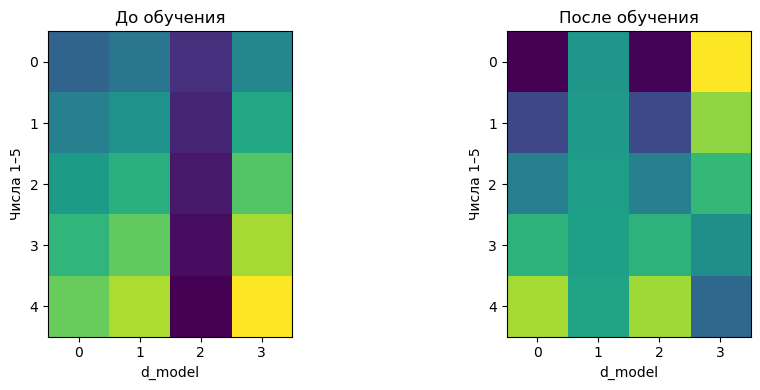

In [213]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Установка случайного зерна
torch.manual_seed(42)

# Параметры
d_model = 4
seq = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])  # последовательность чисел, shape: [5, 1]

# Линейный слой для эмбеддингов
input_proj = nn.Linear(1, d_model)

# Эмбеддинги до обучения
with torch.no_grad():
    before = input_proj(seq).detach().numpy()

# Оптимизатор и фиктивная цель
optimizer = torch.optim.SGD(input_proj.parameters(), lr=0.1)
target = torch.zeros_like(input_proj(seq))  # хотим, чтобы всё стремилось к нулям

# Обучаем 100 шагов
for _ in range(100):
    optimizer.zero_grad()
    out = input_proj(seq)
    loss = ((out - target) ** 2).mean()
    loss.backward()
    optimizer.step()

# Эмбеддинги после обучения
with torch.no_grad():
    after = input_proj(seq).detach().numpy()

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(before, cmap='viridis')
ax1.set_title('До обучения')
ax1.set_xlabel('d_model')
ax1.set_ylabel('Числа 1–5')

ax2.imshow(after, cmap='viridis')
ax2.set_title('После обучения')
ax2.set_xlabel('d_model')
ax2.set_ylabel('Числа 1–5')

plt.tight_layout()
plt.show()
